# Stage 2 — Macro Regime Classifier (V5 Phase 2.12 Final)

**BBL514E Pattern Recognition — Term Project**

## Approach

Stage 2 sınıflandırıcı, S&P 500 + makro değişkenler üzerinden günlük makro rejim etiketi üretir: **Bull / Neutral / Bear**.

Dört kanonik unsupervised yaklaşımı birer kez denedik (`reports/Phase2/v5_phase2.{1,2,5,5b}_*.png`); hepsi yetersiz kaldı:
- **Unsupervised K-Means:** Non-temporal — 2008 GFC yapısını yakalayamadı
- **Semantic Constrained K-Means:** Sınıf semantiği zorlandı ama geçiş kararları noisy
- **HMM 3-state Gaussian:** Temporal ama state geçişleri stabil değil
- **GMM 3-component:** 2024-2025 stickiness — P(Stress) ≈ 0.96 sabit

**Pivot:** Bu 4 denemeden sonra rule-based composite finite-state machine (FSM) yaklaşımına hızlıca geçildi. 8 rule + 1 guard ile hysteresis, dwell time, velocity entries ve macro stress overrides birleştirilir. Bu notebook, Phase 2.12 final yapılandırmasını yeniden üretir.

## Final rule set (Phase 2.12)

| # | Kural | Detay |
|---|---|---|
| 1 | Hysteresis | Bear entry VIX_z>1.0, exit <0.3 / Bull entry VIX_z<-0.5 AND SP500_5d>0 |
| 2 | Dwell time | Bear ≥20d, Bull ≥40d, Neutral ≥10d |
| 3 | Bear→Neutral velocity | ΔVIX_z[10d] < -0.8 |
| 4 | YC persistent inversion | 60d rolling(10Y-2Y) < 0 → Bull→Neutral |
| 5 | DXY+M2 macro stress | DXY_z[30d]>0.7 AND M2_yoy[30d]<0.040 → Bull→Neutral |
| 6 | Bull velocity entry | ΔVIX_z[30d]<-0.6 AND SP500_60d>+2% (V-shape) |
| 7 | Bear velocity entry | ΔVIX_z[5d]>+0.6 AND SP500_5d<-1.5% (rapid escalation) |
| 8 | Bear re-entry guard | Bear→Neutral sonrası 35d Neutral şart |

In [1]:
import sys
from pathlib import Path
PROJECT_ROOT = Path.cwd().parent
sys.path.insert(0, str(PROJECT_ROOT))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from src.labels.v5_regime_labels import CompositeVIXRegimeClassifier, BULL_BEAR_LABELS

plt.rcParams.update({"figure.dpi": 110, "font.size": 11})

## 1. Load pretrain macro features

In [2]:
proc = PROJECT_ROOT / "data" / "processed"
raw = PROJECT_ROOT / "data" / "raw"

pretrain = pd.read_csv(proc / "macro_derived_pretrain_v5.csv", index_col=0, parse_dates=True)
sp500_raw = pd.read_csv(raw / "v5_macro_risk.csv", index_col=0, parse_dates=True)["SP500"]
pretrain["SP500_60d_return"] = (sp500_raw / sp500_raw.shift(60) - 1.0).reindex(pretrain.index)

pretrain_clean = pretrain.dropna(subset=["VIX_zscore_long", "SP500_log_return_5d",
                                          "Yield_Curve_10Y_2Y", "DXY_zscore_long",
                                          "M2_yoy_change", "SP500_60d_return"])
print(f"Pretrain rows: {len(pretrain_clean)}, span: {pretrain_clean.index.min().date()} → {pretrain_clean.index.max().date()}")
pretrain_clean[["VIX_zscore_long", "SP500_log_return_5d", "Yield_Curve_10Y_2Y", "DXY_zscore_long", "M2_yoy_change"]].tail()

Pretrain rows: 6259, span: 2001-01-03 → 2025-12-30


,VIX_zscore_long,SP500_log_return_5d,Yield_Curve_10Y_2Y,DXY_zscore_long,M2_yoy_change
2025-12-23,-0.696867,0.015978,0.689,0.449630,0.035917
2025-12-24,-0.760443,0.030855,0.666,0.453175,0.034304
2025-12-26,-0.744849,0.013868,0.676,0.456719,0.034304
2025-12-29,-0.672876,0.003954,0.666,0.458492,0.038078
2025-12-30,-0.657282,-0.001963,0.680,0.476217,0.038078


## 2. Fit Phase 2.12 Composite Macro FSM

In [3]:
model = CompositeVIXRegimeClassifier(
    bear_entry_threshold=1.0, bear_exit_threshold=0.3,
    bull_entry_threshold=-0.5, bull_exit_threshold=0.0,
    bear_min_dwell=20, bull_min_dwell=40,
    velocity_window=10, velocity_threshold=-0.8, velocity_sp500_min=0.0,
    initial_regime="Neutral",
    enable_yield_curve_override=True,
    yield_curve_persistence_window=60,
    yield_curve_blocks_bull_entry=False,
    enable_macro_stress_override=True,
    dxy_strong_threshold=0.7, m2_low_threshold=0.040,
    macro_stress_window=30, macro_stress_combine="AND",
    enable_bull_velocity_entry=True,
    bull_velocity_window=30, bull_velocity_threshold=-0.6, bull_velocity_sp500_min=0.02,
    enable_bear_velocity_entry=True,
    bear_velocity_entry_window=5, bear_velocity_entry_threshold=0.6,
    bear_velocity_entry_sp500_max=-0.015,
    bear_reentry_min_neutral_dwell=35, neutral_min_dwell=10,
).fit(pretrain_clean)

pre_r = model.predict(pretrain_clean)
print(f"Override fires:")
print(f"  Bear→Neutral velocity: {pre_r['velocity_override'].sum()}")
print(f"  Bull velocity entry:   {pre_r['bull_velocity_entry'].sum()}")
print(f"  Bear velocity entry:   {pre_r['bear_velocity_entry'].sum()}")
print(f"  YC override:           {pre_r['yield_curve_override'].sum()}")
print(f"  Macro stress (DXY+M2): {pre_r['macro_stress_override'].sum()}")

Override fires:
  Bear→Neutral velocity: 27
  Bull velocity entry:   32
  Bear velocity entry:   29
  YC override:           13
  Macro stress (DXY+M2): 2


## 3. Apply to BTC and ETH eras (forward-fill)

In [4]:
btc = pd.read_csv(proc / "btc_aligned_v5.csv", index_col=0, parse_dates=True)
eth = pd.read_csv(proc / "eth_aligned_v5.csv", index_col=0, parse_dates=True)
btc_r = pre_r.reindex(btc.index, method="ffill")
eth_r = pre_r.reindex(eth.index, method="ffill")

rows = []
for label, df in [("Pre-train", pre_r), ("BTC era", btc_r), ("ETH era", eth_r)]:
    c = df["regime_label"].value_counts()
    total = c.sum()
    rows.append({"period": label, **{r: f"{c.get(r, 0)} ({c.get(r, 0)/total*100:.1f}%)" for r in BULL_BEAR_LABELS}})
pd.DataFrame(rows).set_index("period")

,Bull,Neutral,Bear
period,,,
Pre-train,3954 (63.2%),1501 (24.0%),804 (12.8%)
BTC era,2813 (68.7%),838 (20.5%),443 (10.8%)
ETH era,1934 (65.4%),695 (23.5%),326 (11.0%)


## 4. Final timeline plot (S&P 500 + BTC + ETH + composite regime)

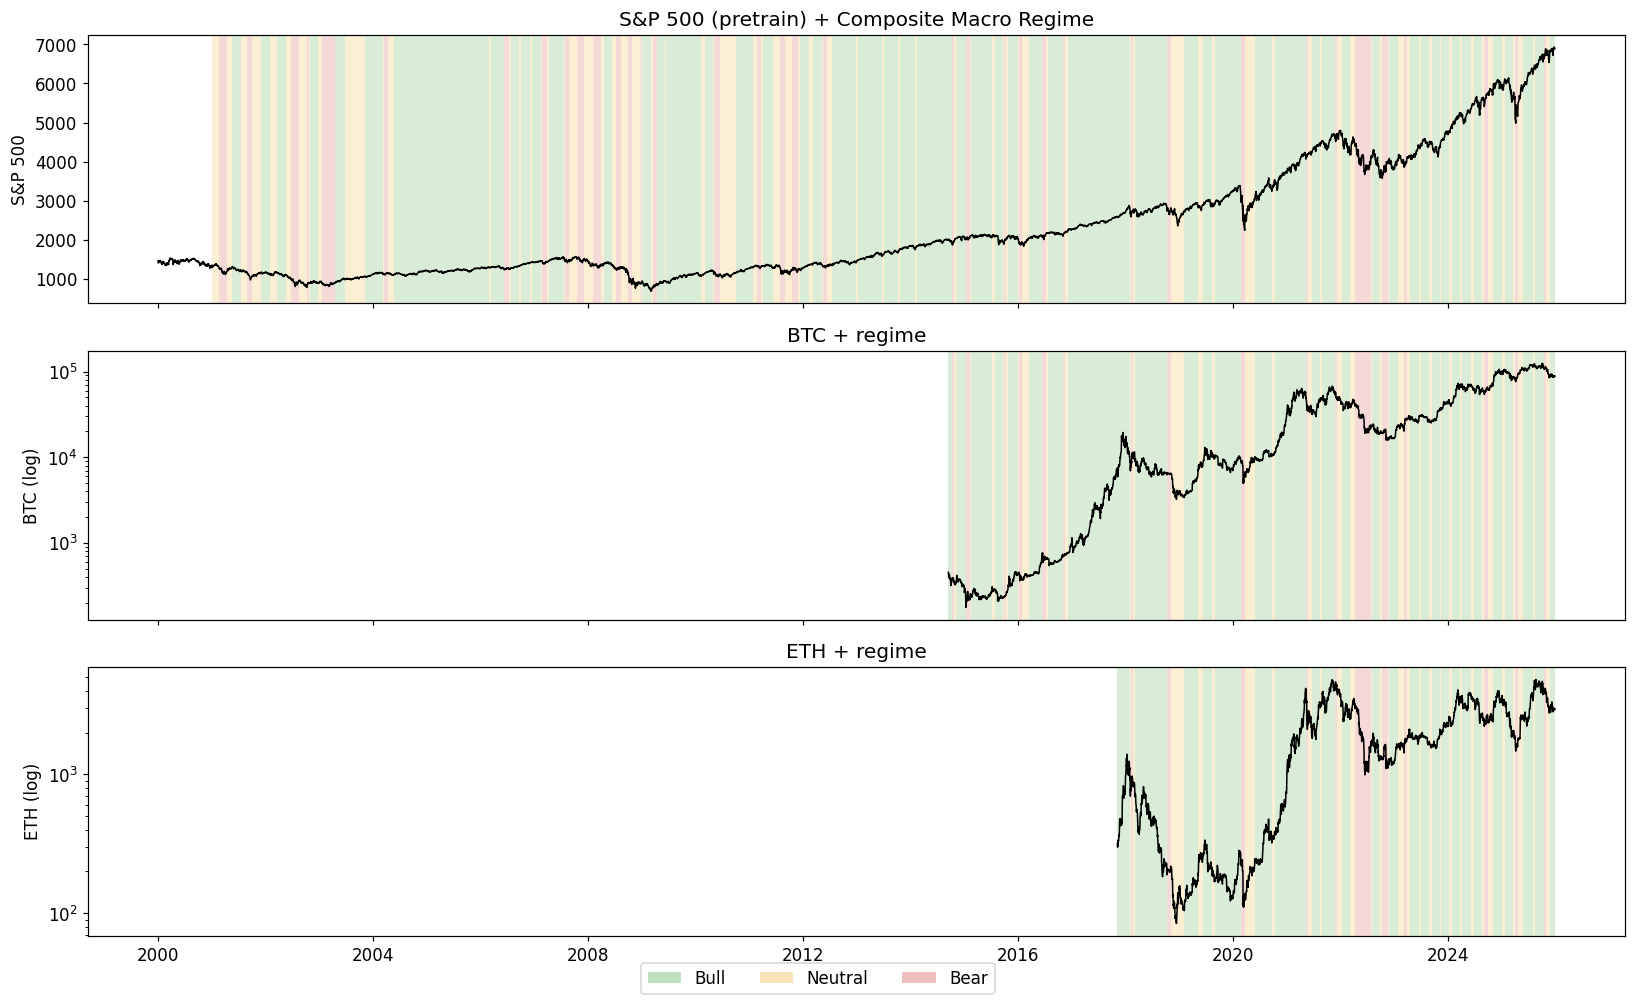

In [5]:
from matplotlib.patches import Patch
REGIME_COLORS = {"Bull": "#7ec27e", "Neutral": "#f0c870", "Bear": "#e07e7e"}

def shade(ax, regime):
    cur, start = regime.iloc[0], regime.index[0]
    for i in range(1, len(regime)):
        v = regime.iloc[i]
        if v != cur:
            ax.axvspan(start, regime.index[i], color=REGIME_COLORS[cur], alpha=0.30, lw=0)
            cur, start = v, regime.index[i]
    ax.axvspan(start, regime.index[-1], color=REGIME_COLORS[cur], alpha=0.30, lw=0)

sp500 = sp500_raw.dropna()
fig, axes = plt.subplots(3, 1, figsize=(15, 9), sharex=True)
shade(axes[0], pre_r["regime_label"])
axes[0].plot(sp500.index, sp500.values, color="black", lw=1.0)
axes[0].set_ylabel("S&P 500"); axes[0].set_title("S&P 500 (pretrain) + Composite Macro Regime")
shade(axes[1], btc_r["regime_label"])
axes[1].semilogy(btc["Close"].index, btc["Close"].values, color="black", lw=1.0)
axes[1].set_ylabel("BTC (log)"); axes[1].set_title("BTC + regime")
shade(axes[2], eth_r["regime_label"])
axes[2].semilogy(eth["Close"].index, eth["Close"].values, color="black", lw=1.0)
axes[2].set_ylabel("ETH (log)"); axes[2].set_title("ETH + regime")
handles = [Patch(facecolor=c, alpha=0.5, label=r) for r, c in REGIME_COLORS.items()]
fig.legend(handles=handles, loc="lower center", ncol=3, bbox_to_anchor=(0.5, -0.02))
fig.tight_layout()
plt.show()

## 5. Save regime labels for downstream stages

Stage 3 (signal classifier) bu CSV'leri soft fusion input olarak kullanır.

In [6]:
pre_r.to_csv(proc / "macro_pretrain_regime_labels_composite_macro_v5_v5.csv")
btc_r.to_csv(proc / "btc_regime_labels_composite_macro_v5_v5.csv")
eth_r.to_csv(proc / "eth_regime_labels_composite_macro_v5_v5.csv")
print("Saved 3 regime label CSVs.")

Saved 3 regime label CSVs.


## Summary

**Crises caught (Bear regime):** 2008-09 GFC, 2018 Q4, 2020-03 COVID, 2022 Q2-Q4, 2025-04 tariff.

**Recoveries caught (Bull velocity entry):** 2003 dot-com, 2009 GFC, 2020 V-shape, 2022 Q4-2023 Q1, 2025 May.

Pretrain distribution: Bull 63%, Neutral 24%, Bear 13%. BTC era: 69/21/11. ETH era: 65/24/11.

Stage 2 output (regime probabilities P_Bull, P_Neutral, P_Bear) Stage 3 sinyal sınıflandırıcısına soft fusion ile geçer.